# THIWASCO Leak Detection - Data Exploration

## Overview
This notebook explores the THIWASCO leak detection dataset to understand:
- Data quality and structure
- Leak type distributions
- Feature patterns and correlations
- Model performance insights

## Pipeline Context
```
generate_scenarios.py -> data_builder.py -> feature_extractor.py -> train_model.py
```

In [36]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.append(str(Path().absolute().parent / 'src'))

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load Data

In [37]:
# Load data with enhanced features
from utils.config import PROCESSED_DIR, MODELS_DIR

try:
    # Load engineered features
    df = pd.read_csv(PROCESSED_DIR / "engineered_features.csv")
    print(f"Loaded engineered features: {df.shape}")
    
    # Check for enhanced features
    enhanced_features = [
        'flow_burst_magnitude', 'pressure_drop_magnitude',
        'instant_flow_jump', 'instant_pressure_drop',
        'moderate_flow_sustained', 'moderate_pressure_sustained',
        'high_demand_flow_ratio', 'flow_pattern_consistency',
        'pressure_pattern_consistency'
    ]
    
    available_enhanced = [f for f in enhanced_features if f in df.columns]
    print(f"Enhanced features available: {len(available_enhanced)}/{len(enhanced_features)}")
    
    if len(available_enhanced) > 0:
        print("Enhanced features found:")
        for feat in available_enhanced[:3]:
            print(f"  - {feat}")
        if len(available_enhanced) > 3:
            print(f"  ... and {len(available_enhanced) - 3} more")
    else:
        print("Using baseline features only")
        
    # Display basic info
    print(f"\nDataset Info:")
    print(f"  Scenarios: {df['scenario'].nunique()}")
    print(f"  Time steps: {df['time_index'].nunique()}")
    print(f"  Total records: {len(df)}")
    print(f"  Features: {len(df.columns)}")
    
except FileNotFoundError:
    print("Data file not found. Please run the pipeline first:")
    print("python run_pipeline.py")
    df = None

Loaded engineered features: (72000, 42)
Enhanced features available: 9/9
Enhanced features found:
  - flow_burst_magnitude
  - pressure_drop_magnitude
  - instant_flow_jump
  ... and 6 more

Dataset Info:
  Scenarios: 3000
  Time steps: 24
  Total records: 72000
  Features: 42


## Data Quality Analysis

In [38]:
# Basic data quality checks
print("=== DATA QUALITY REPORT ===")
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Data types:")
print(df.dtypes.value_counts())

# Check for infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_values = (df[numeric_cols] == np.inf).sum().sum()
print(f"Infinite values: {inf_values}")

=== DATA QUALITY REPORT ===
Dataset shape: (72000, 42)
Missing values: 177000
Duplicate rows: 0
Data types:
float64    35
int64       6
object      1
dtype: int64
Infinite values: 0


## Leak Type Distribution

Available columns:
['scenario', 'time_index', 'mean_flow', 'mean_pressure', 'scenario_has_leak', 'leak_type', 'mean_pressure_s', 'mean_pressure_roll', 'mean_pressure_delta', 'mean_flow_s', 'mean_flow_roll', 'mean_flow_delta', 'p_mu', 'p_std', 'f_mu', 'f_std', 'z_p', 'z_f', 'flow_slope', 'pressure_velocity', 'is_night', 'flow_roll_12h', 'flow_roll_18h', 'flow_burst_magnitude', 'pressure_drop_magnitude', 'instant_flow_jump', 'instant_pressure_drop', 'moderate_flow_sustained', 'moderate_pressure_sustained', 'is_high_demand', 'high_demand_flow_ratio', 'flow_pattern_consistency', 'pressure_pattern_consistency', 'flow_excess_cumulative', 'pressure_trend_consistency', 'flow_jump_magnitude', 'pressure_drop_sudden', 'first_hour_delta', 'burst_position', 'flow_vs_expected', 'pressure_demand_ratio', 'masking_detection']

Leak-related columns: ['scenario_has_leak', 'leak_type']
Using column: scenario_has_leak


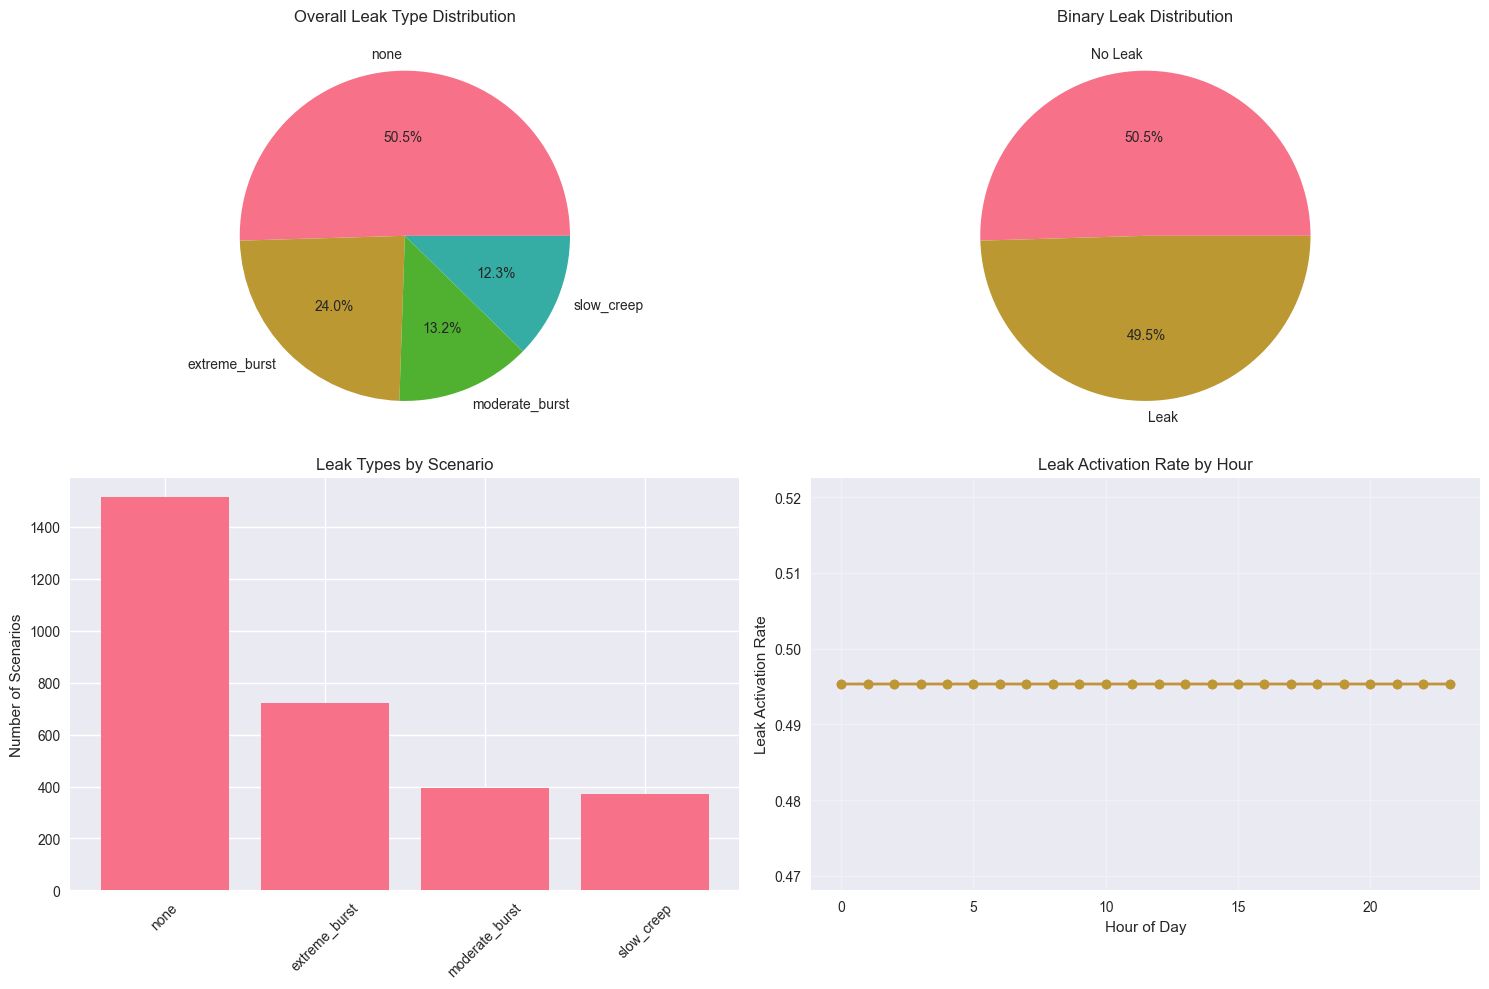

=== LEAK DISTRIBUTION SUMMARY ===
Total scenarios: 3000
Total timesteps: 72000

Leak types by count:
none              36336
extreme_burst     17280
moderate_burst     9504
slow_creep         8880
Name: leak_type, dtype: int64

Leak types by scenario:
none              1514
extreme_burst      720
moderate_burst     396
slow_creep         370
Name: leak_type, dtype: int64


In [39]:
# Leak distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Overall leak distribution
leak_counts = df['leak_type'].value_counts()
axes[0,0].pie(leak_counts.values, labels=leak_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Overall Leak Type Distribution')

# 2. Binary leak distribution
binary_counts = df['scenario_has_leak'].value_counts()
axes[0,1].pie(binary_counts.values, labels=['No Leak', 'Leak'], autopct='%1.1f%%')
axes[0,1].set_title('Binary Leak Distribution')

# 3. Leak types by scenario
scenario_leaks = df.groupby('scenario')['leak_type'].first().value_counts()
axes[1,0].bar(scenario_leaks.index, scenario_leaks.values)
axes[1,0].set_title('Leak Types by Scenario')
axes[1,0].set_ylabel('Number of Scenarios')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Leak activation over time
# First, let's check what columns are actually available in the DataFrame
print("Available columns:")
print(df.columns.tolist())

# 4. Leak activation over time - using the correct column name
# check what leak-related columns exist
leak_columns = [col for col in df.columns if 'leak' in col.lower()]
print(f"\nLeak-related columns: {leak_columns}")

# Use the appropriate leak column name
if 'leak_active_at_timestep' in df.columns:
    hourly_leaks = df.groupby('time_index')['leak_active_at_timestep'].mean()
elif 'leak_active' in df.columns:
    hourly_leaks = df.groupby('time_index')['leak_active'].mean()
elif leak_columns:
    # Use the first leak-related column found
    hourly_leaks = df.groupby('time_index')[leak_columns[0]].mean()
    print(f"Using column: {leak_columns[0]}")
else:
    print("No leak-related columns found. Skipping this plot.")
    hourly_leaks = None

if hourly_leaks is not None:
    axes[1,1].plot(hourly_leaks.index, hourly_leaks.values, marker='o')
    axes[1,1].set_title('Leak Activation Rate by Hour')
    axes[1,1].set_xlabel('Hour of Day')
    axes[1,1].set_ylabel('Leak Activation Rate')
    axes[1,1].grid(True, alpha=0.3)
axes[1,1].plot(hourly_leaks.index, hourly_leaks.values, marker='o')
axes[1,1].set_title('Leak Activation Rate by Hour')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Leak Activation Rate')

plt.tight_layout()
plt.show()

print("=== LEAK DISTRIBUTION SUMMARY ===")
print(f"Total scenarios: {df['scenario'].nunique()}")
print(f"Total timesteps: {len(df)}")
print(f"\nLeak types by count:")
print(leak_counts)
print(f"\nLeak types by scenario:")
print(scenario_leaks)

## Feature Analysis

In [40]:
# Identify feature columns
feature_cols = [col for col in df.columns if col not in [
    'scenario', 'time_index', 'scenario_has_leak', 'leak_type', 
    'leak_active_at_timestep'
]]

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature categories:")

# Categorize features
z_features = [col for col in feature_cols if 'z_' in col]
delta_features = [col for col in feature_cols if 'delta' in col]
rolling_features = [col for col in feature_cols if 'roll' in col]
slope_features = [col for col in feature_cols if 'slope' in col]
other_features = [col for col in feature_cols if not any(
    prefix in col for prefix in ['z_', 'delta', 'roll', 'slope']
)]

print(f"Z-score features: {len(z_features)}")
print(f"Delta features: {len(delta_features)}")
print(f"Rolling features: {len(rolling_features)}")
print(f"Slope features: {len(slope_features)}")
print(f"Other features: {len(other_features)}")

print(f"\nSample features:")
for category, features in [
    ('Z-score', z_features[:3]),
    ('Delta', delta_features[:3]),
    ('Rolling', rolling_features[:3]),
]:
    print(f"{category}: {features}")

Number of features: 38

Feature categories:
Z-score features: 2
Delta features: 3
Rolling features: 4
Slope features: 1
Other features: 28

Sample features:
Z-score: ['z_p', 'z_f']
Delta: ['mean_pressure_delta', 'mean_flow_delta', 'first_hour_delta']
Rolling: ['mean_pressure_roll', 'mean_flow_roll', 'flow_roll_12h']


## Feature Correlation Analysis

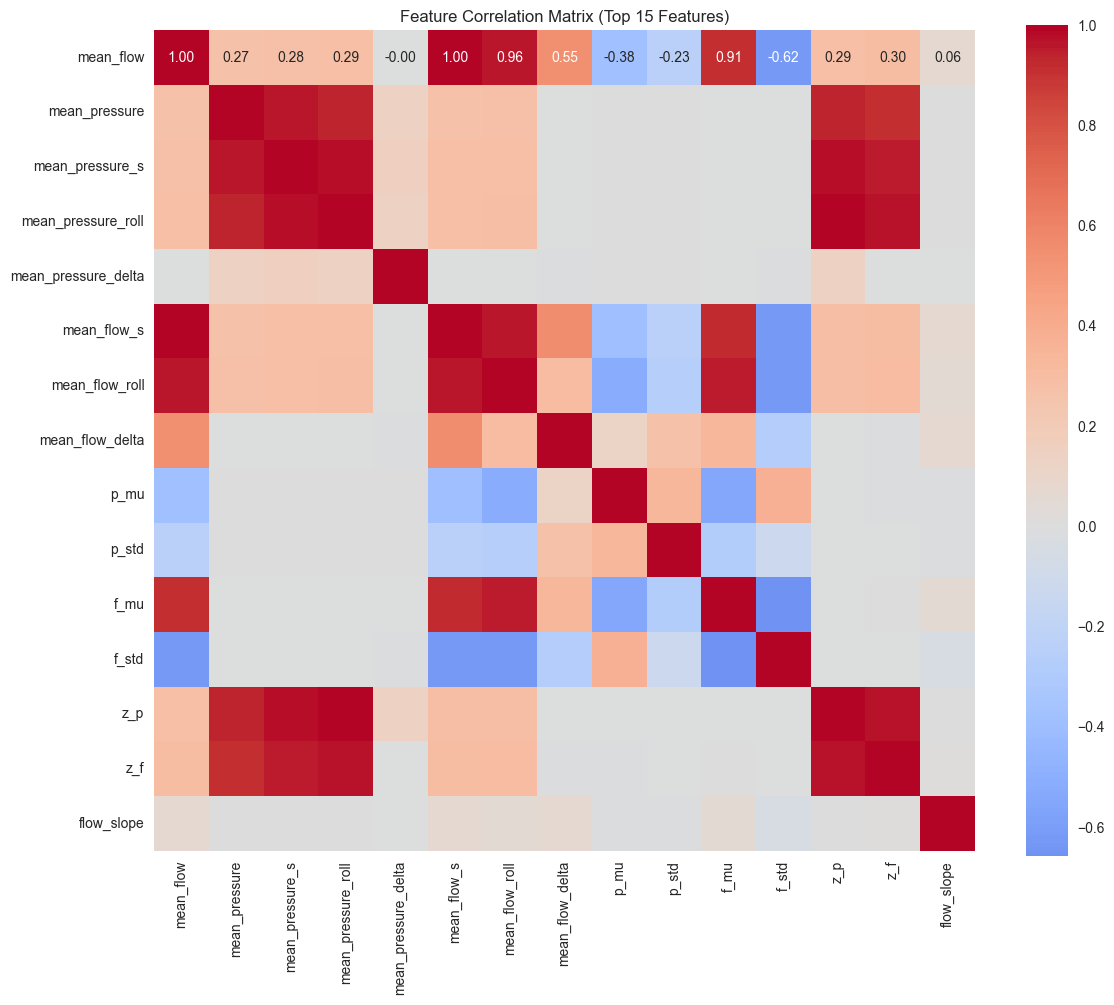


Highly correlated feature pairs (|r| > 0.8):
mean_flow <-> mean_flow_s: 0.998
mean_flow <-> mean_flow_roll: 0.959
mean_flow <-> f_mu: 0.913
mean_pressure <-> mean_pressure_s: 0.960
mean_pressure <-> mean_pressure_roll: 0.937
mean_pressure <-> z_p: 0.937
mean_pressure <-> z_f: 0.916
mean_pressure_s <-> mean_pressure_roll: 0.979
mean_pressure_s <-> z_p: 0.979
mean_pressure_s <-> z_f: 0.954


In [41]:
# Correlation matrix for top features
top_features = feature_cols[:15]  # First 15 features
corr_matrix = df[top_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix (Top 15 Features)')
plt.tight_layout()
plt.show()

# Find highly correlated features
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated feature pairs (|r| > 0.8):")
for feat1, feat2, corr in high_corr_pairs[:10]:
    print(f"{feat1} <-> {feat2}: {corr:.3f}")

## Leak Pattern Visualization

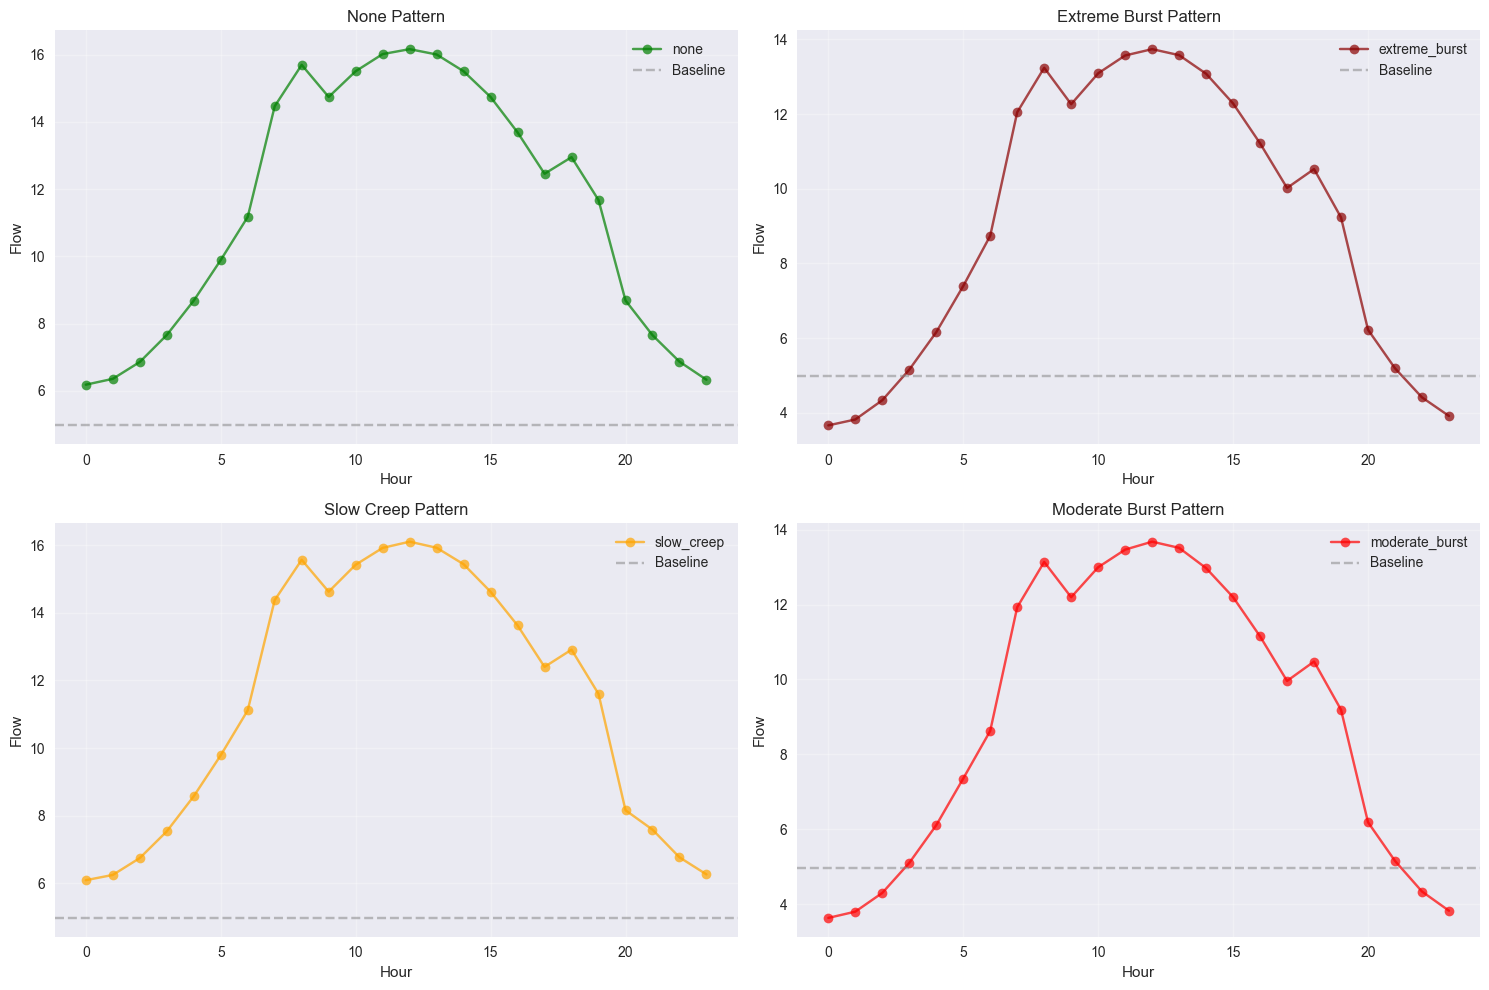

=== LEAK PATTERN ANALYSIS ===
Each plot shows a representative scenario for each leak type
Notice the different patterns in flow behavior over time


In [42]:
# Visualize different leak patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sample scenarios for each leak type
leak_types = df['leak_type'].unique()
colors = {'none': 'green', 'slow_creep': 'orange', 'moderate_burst': 'red', 'extreme_burst': 'darkred'}

for i, leak_type in enumerate(leak_types):
    ax = axes[i//2, i%2]
    
    # Get a sample scenario for this leak type
    sample_scenario = df[df['leak_type'] == leak_type]['scenario'].iloc[0]
    scenario_data = df[df['scenario'] == sample_scenario].sort_values('time_index')
    
    # Plot flow pattern
    ax.plot(scenario_data['time_index'], scenario_data['mean_flow'], 
            'o-', color=colors[leak_type], label=leak_type, alpha=0.7)
    
    # Add baseline for reference
    baseline = scenario_data['f_mu'].iloc[0]
    ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5, label='Baseline')
    
    ax.set_title(f'{leak_type.replace("_", " ").title()} Pattern')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Flow')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== LEAK PATTERN ANALYSIS ===")
print("Each plot shows a representative scenario for each leak type")
print("Notice the different patterns in flow behavior over time")

## Feature Distribution by Leak Type

In [43]:
# Box plots of key features by leak type
key_features = ['z_f_mean', 'z_f_std', 'mean_flow_delta_last', 'flow_slope_max']
available_features = [f for f in key_features if f in df.columns]

if available_features:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(available_features):
        if i < len(axes):
            # Create box plot
            sns.boxplot(data=df, x='leak_type', y=feature, ax=axes[i])
            axes[i].set_title(f'{feature} by Leak Type')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(available_features), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("=== FEATURE DISTRIBUTION ANALYSIS ===")
    print("Box plots show how key features differ across leak types")
    print("Look for features that clearly separate leak types")
else:
    print("Key features not found in dataset")

Key features not found in dataset


## Summary Statistics

In [44]:
# Generate summary statistics
print("=== DATASET SUMMARY ===")
print(f"Total records: {len(df):,}")
print(f"Total scenarios: {df['scenario'].nunique():,}")
print(f"Hours per scenario: {len(df) // df['scenario'].nunique()}")
print(f"Feature columns: {len(feature_cols)}")

print(f"\n=== LEAK STATISTICS ===")
leak_stats = df.groupby('leak_type').agg({
    'scenario': 'nunique',
    'scenario_has_leak': 'first',
    'mean_flow': ['mean', 'std'],
    'mean_pressure': ['mean', 'std']
}).round(3)

print(leak_stats)

print(f"\n=== FEATURE STATISTICS ===")
if feature_cols:
    feature_stats = df[feature_cols].describe().round(3)
    print(feature_stats.loc[['count', 'mean', 'std', 'min', 'max']])

=== DATASET SUMMARY ===
Total records: 72,000
Total scenarios: 3,000
Hours per scenario: 24
Feature columns: 38

=== LEAK STATISTICS ===
               scenario scenario_has_leak mean_flow        mean_pressure  \
                nunique             first      mean    std          mean   
leak_type                                                                  
extreme_burst       720                 1    10.318  3.852        39.737   
moderate_burst      396                 1    10.444  3.838        40.380   
none               1514                 0    10.297  3.840        39.927   
slow_creep          370                 1    10.274  3.843        39.763   

                       
                  std  
leak_type              
extreme_burst   4.956  
moderate_burst  4.913  
none            4.994  
slow_creep      4.978  

=== FEATURE STATISTICS ===
       mean_flow  mean_pressure  mean_pressure_s  mean_pressure_roll  \
count  72000.000      72000.000        72000.000           720

## Key Insights

### Data Quality
- Check for missing values and data integrity
- Verify feature distributions are reasonable
- Identify any outliers or anomalies

### Leak Patterns
- Analyze how different leak types manifest in the data
- Identify distinguishing characteristics of each leak type
- Understand temporal patterns in leak activation

### Feature Effectiveness
- Determine which features best separate leak types
- Identify redundant or highly correlated features
- Assess feature distributions for model suitability

### Next Steps
- Use insights to improve feature engineering
- Inform model selection and hyperparameter tuning
- Guide additional data collection or simulation improvements